<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
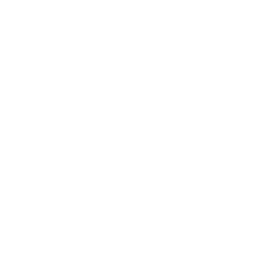
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">화학 반응기 열적 이상 진단</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 이상 이벤트 동안 반응기 T2 한계 초과를 유발하는 변수 식별 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

연속교반탱크반응기(CSTR)는 냉각수 공급이 저하되면서 열적 이상(thermal upset) 상태로
접어들었습니다. 정상 운전 시에는 냉각수 유량, 반응기 온도, 재킷 온도가 하나의 공정
부하(process-load) 축을 따라 함께 움직입니다. 정상 운전 관측치 100건으로 3개 성분의
MVP 모형을 구축한 다음, `PROC MVPDIAGNOSE`로 이상 관측치 100건을 이 모형에 대해
채점합니다. Hotelling의 *T*-제곱 통계량을 변수별 기여도로 분해하면 열적으로 결합된
세 변수 — `jacket_temp`, `coolant_flow`, `reactor_temp` — 가 한계 초과를 주도하는
변수임이 드러나며, 이는 곧바로 냉각수 서브시스템을 가리킵니다.

## 데이터 출처

| 데이터셋 | 역할 | 관측치 수 |
|---|---|---|
| `reactor_normal` | MVP 모형을 위한 정상 운전 학습 데이터 | 100 |
| `reactor_upset` | 모형에 대해 채점되는 이상 이벤트 관측치 | 100 |

측정된 다섯 개 변수는 `reactor_temp` (C, 반응기 온도), `coolant_flow`
(L/min, 냉각수 유량), `jacket_temp` (C, 재킷 온도), `feed_conc` (g/L, 공급 농도),
`pressure` (bar, 압력)입니다. 두 데이터셋 모두 공유된 잠재 *공정 부하*로부터
시뮬레이션되어, 정상 데이터는 실제 CSTR과 동일한 상관구조를 가지며; 이상 데이터는
이 구조를 깨뜨리는 냉각수 공급 손실을 주입합니다.

## 1단계 — 정상 운전 MVP 모형 학습

정상 운전은 잠재 공정 부하에 의해 지배됩니다: 부하가 높아지면 냉각수 유량은
낮아지고 반응기·재킷 온도는 높아집니다. `PROC MVPMODEL`은 100개의 정상 관측치에서
3개의 주성분을 추출하고 `OUTMODEL=`로 저장하여, 진단 단계가 동일한 참조 모형에
대해 새 데이터를 채점할 수 있도록 합니다.

In [1]:
데이터 reactor_normal;
  호출 streaminit(7);
  반복 t = 1 까지 100;
    load = rand('normal', 0, 1);                 /* 잠재 공정 부하 */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    출력;
  종료;
실행;

처리 mvpmodel 데이터=reactor_normal outmodel=reactor_model;
  변수 reactor_temp coolant_flow jacket_temp feed_conc pressure;
  라벨 reactor_temp='반응기 온도' coolant_flow='냉각수 유량'
        jacket_temp='재킷 온도' feed_conc='공급 농도' pressure='압력';
  ncomp=3;
실행;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
             반응기 온도    냉각수 유량     재킷 온도     공급 농도        압력
  반응기 온도    1.0000   -0.9611    0.9530   -0.0726    0.9662
  냉각수 유량   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  재킷 온도     0.9530   -0.9636    1.0000    0.0008    0.9720
  공급 농도    -0.0726    0.0281    0.0008    1.0000   -0.0326
  압력        0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## 2단계 — 이상 이벤트 채점 및 *T*-제곱 분해

이상 이벤트는 냉각수 유량을 약 12 L/min 낮추는 동안 반응기와 재킷 온도는
치솟습니다 — 정상적인 냉각수/온도 결합이 깨진 것입니다. `PROC MVPDIAGNOSE`는
각 이상 관측치를 참조 모형에 대해 채점하여, 표준화된 점수와 잔차를 `OUT=`에,
변수별 *T*-제곱 기여도를 `OUTCONTRIB=`에 기록합니다. 모든 관측치가 관리 한계를
크게 벗어나며, 이는 개별 노이즈가 아닌 지속적인 다변량 이탈임을 확인해 줍니다.

In [2]:
데이터 reactor_upset;
  호출 streaminit(101);
  반복 t = 1 까지 100;
    load = rand('normal', 0, 1);
    /* 냉각수 펌프 노후화: 유량은 감소하고 온도는 폭주 */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    출력;
  종료;
실행;

처리 mvpdiagnose 데이터=reactor_upset 모형=reactor_model
                 out=reactor_scores;
  변수 reactor_temp coolant_flow jacket_temp feed_conc pressure;
  라벨 reactor_temp='반응기 온도' coolant_flow='냉각수 유량'
        jacket_temp='재킷 온도' feed_conc='공급 농도' pressure='압력';
  id obs_time;
  outcontrib=reactor_contrib;
실행;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100
  Variables Diagnosed: 반응기 온도, 냉각수 유량, 재킷 온도, 공급 농도, 압력

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## 3단계 — 평균 기여도 순위 매기기

`OUTCONTRIB=`은 채점된 관측치마다 한 행씩, 각 공정 변수에 대한
`<variable>_CONTRIB` 컬럼을 기록합니다. 이 컬럼들을 평균하면 각 변수가 이상에
기여한 평균값을 얻을 수 있으며, TRANSPOSE로 한 행짜리 요약을 변수/값 형태의
정갈한 표로 재구성해 결함 요인의 순위를 매깁니다.

In [3]:
처리 평균 데이터=reactor_contrib mean NOPRINT;
  변수 reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  출력 out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
실행;

처리 전치 데이터=contrib_means out=contrib_long name=metric;
  변수 mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
실행;

/* 읽기 쉬운 변수 이름과 평균 기여도 값을 붙입니다 */
데이터 contrib_ranked;
  설정 contrib_long;
  길이 variable $40;
  만약      metric = 'mc_reactor_temp' 이면 variable = '반응기 온도';
  아니면 만약 metric = 'mc_coolant_flow' 이면 variable = '냉각수 유량';
  아니면 만약 metric = 'mc_jacket_temp'  이면 variable = '재킷 온도';
  아니면 만약 metric = 'mc_feed_conc'    이면 variable = '공급 농도';
  아니면 만약 metric = 'mc_pressure'     이면 variable = '압력';
  mean_contrib = col1;
  유지 variable mean_contrib;
실행;

처리 정렬 데이터=contrib_ranked;
  기준 DESCENDING mean_contrib;
실행;

처리 인쇄 데이터=contrib_ranked noobs;
  변수 variable mean_contrib;
  라벨 variable='공정 변수' mean_contrib='평균 T-제곱 기여도';
실행;



           공정 변수                평균 T-제곱 기여도
----------------  -------------------------
재킷 온도                         4177.66720283
냉각수 유량                        2882.19501987
반응기 온도                        1602.04200377
압력                             280.73140863
공급 농도                           61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/ae588ce9-0f1a-42dd-ac9c-76aa3d7faf5a/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## 4단계 — 기여도 그래프

기여도 그래프는 진단을 한눈에 보여줍니다: 열적으로 결합된 세 변수 —
`jacket_temp`, `coolant_flow`, `reactor_temp` — 가 `feed_conc`와 `pressure`를
압도하며, 후자 둘은 거의 눈에 띄지 않습니다. 가장 큰 세 개의 막대는 정확히
냉각 루프로 서로 연결된 변수들이므로, 결함은 명백히 열적인 것이며 공급이나
압력 문제가 아닙니다.


NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


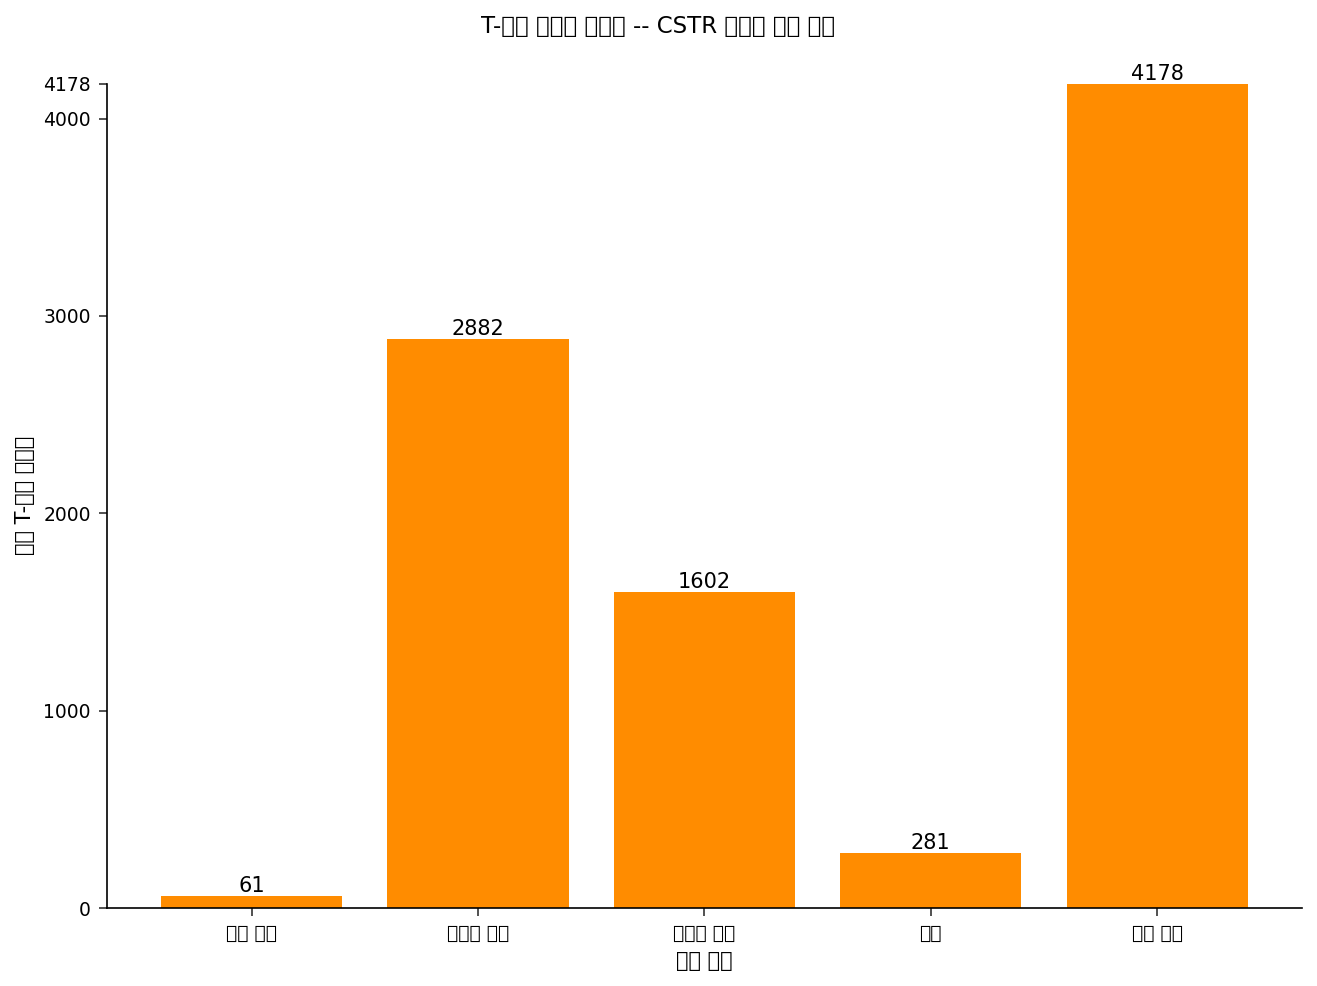

In [4]:
처리 SGPLOT 데이터=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS 라벨='공정 변수';
  YAXIS 라벨='평균 T-제곱 기여도';
  제목 'T-제곱 기여도 그래프 -- CSTR 냉각수 손실 이상';
실행;


## 5단계 — *T*-제곱 관리 시계열

각 관측치의 *T*-제곱을 모형의 관리 한계와 함께 그려보면 이탈이 지속적임을 알
수 있습니다: 모든 이상 관측치가 한계 기준선보다 몇 자릿수 위에 위치합니다.
관측 구간 내내 회복이 없으며, 이는 냉각수 서브시스템이 정비될 때까지 지속되는
하드웨어 결함과 일치합니다.


NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


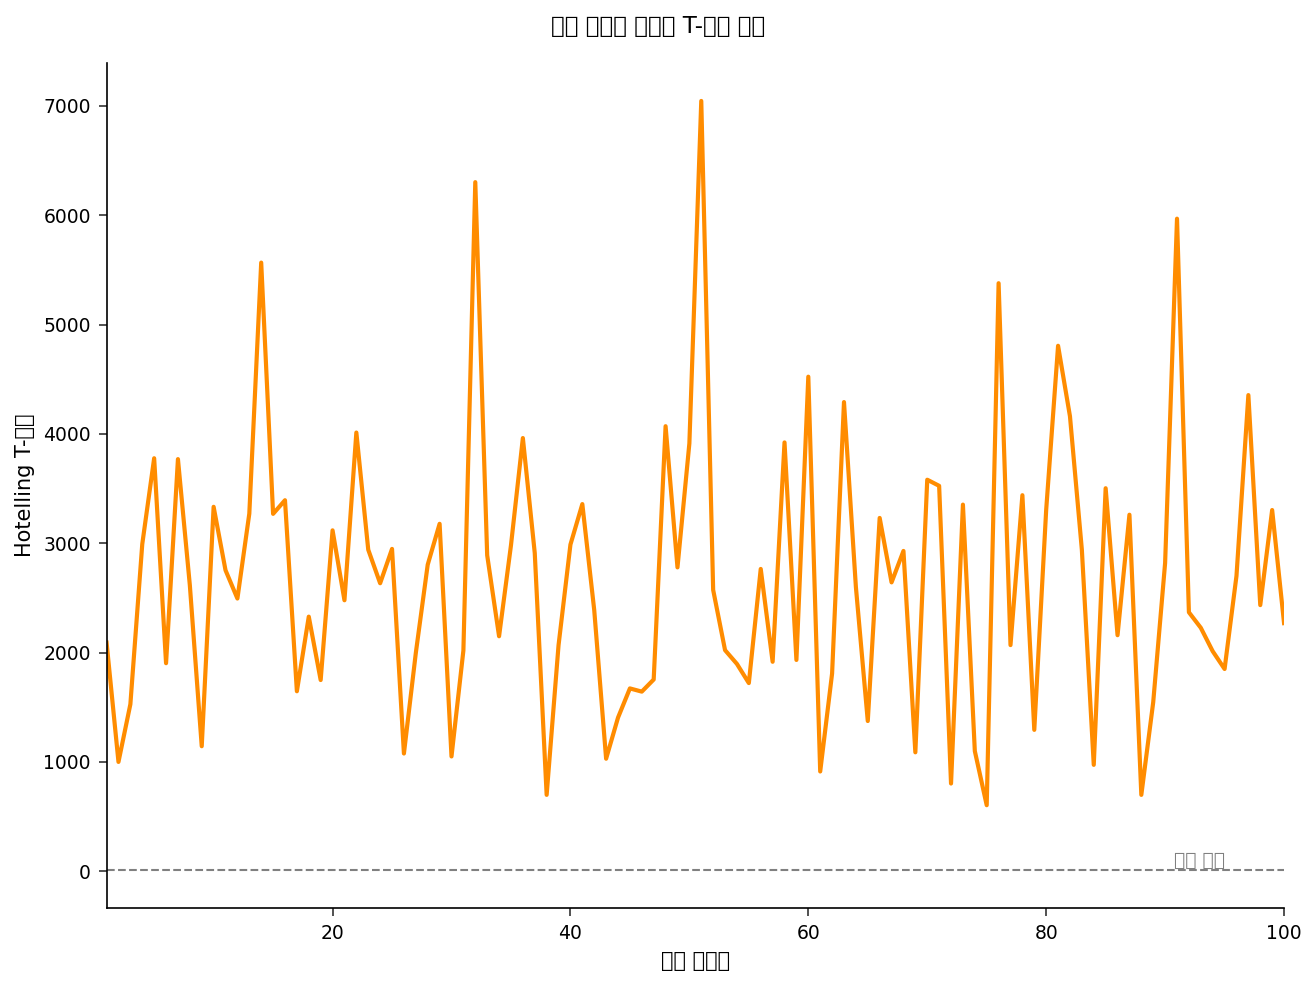

In [5]:
처리 SGPLOT 데이터=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  라벨='관리 한계'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS 라벨='이상 관측치';
  YAXIS 라벨='Hotelling T-제곱';
  제목 '이상 이벤트 동안의 T-제곱 추이';
실행;


## 결과 및 시정 조치

- **주요 요인**: `jacket_temp`, `coolant_flow`, `reactor_temp`가 함께 *T*-제곱
  신호의 사실상 전부를 차지하며, 이들의 평균 기여도는 `feed_conc`와 `pressure`보다
  두세 자릿수 더 큽니다.
- **근본 원인**: 냉각수 공급 손실. 세 변수 중 `coolant_flow`만이 유일한
  *조작(manipulated)* 변수이며 — 온도 상승은 냉각 손실에 따른 하위 결과이므로,
  조치가 필요한 실제 결함은 냉각수 서브시스템입니다.
- **관리 상태**: 이상 관측치 100건 전부가 *T*-제곱 한계를 위반하고 있어, 일시적
  현상이 아니라 지속적인 이탈임을 나타냅니다.
- **시정 조치**: 냉각수 펌프를 점검하고 재정비하며, 향후 공급 손실이 온도 루프로
  전파되기 전에 단변량 경보로 포착되도록 예비 냉각수 유량 트랜스미터를
  추가합니다.

## 순위가 매겨진 기여도 내보내기

순위가 매겨진 기여도 표는 이벤트 이후 보고서와 후속 대시보드를 위해 CSV로
기록됩니다.

In [6]:
처리 EXPORT 데이터=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
실행;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 대외비
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>